# Exploratory Data Analysis
**Project:** Knowledge, Attitudes, and Practices Toward Telemedicine Among Primary Healthcare Physicians in Sudan – 2026

**Data analyst:** Abdulrahman Sirelkhatim

In [ ]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 11

DATA_PATH = "../1_data/cleaned/cleaned_data.xlsx"
df = pd.read_excel(DATA_PATH)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (251, 59)


,B1_Age,B2_Gender,B3_State,B4_WorkSetting,B5_YearsExp,B6_Qualification,B7_Training,K1_InformedConsent,K2_WrittenConsent,K3_ReduceTravel,...,P5_NoTraining,P5_NoEquip,P5_PtResist,P5_Legal,P5_NoBarrier,P6_TechTrain,P6_Internet,P6_Guidelines,P6_Equipment,P6_Financial
0,2.0,1.0,Kassala,2.0,1.0,2.0,0.0,1.0,9.0,1.0,...,1,1,0,0,0,1,1,1,1,0
1,2.0,1.0,White Nile,3.0,2.0,3.0,1.0,1.0,1.0,1.0,...,0,0,1,0,0,1,1,0,0,1
2,2.0,2.0,Khartoum,1.0,2.0,1.0,1.0,1.0,1.0,1.0,...,0,0,0,0,0,1,0,0,0,0


## 1. Data Quality

In [2]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "None")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nN = {len(df)} (after eligibility filter applied in cleaning.py)")

Missing values per column:
B1_Age                  1
B2_Gender               1
B3_State                1
B4_WorkSetting          1
B5_YearsExp             1
B6_Qualification        1
B7_Training             1
K1_InformedConsent      1
K2_WrittenConsent       1
K3_ReduceTravel         1
K4_VideoMandatory       1
K5_ControlledMeds       1
K6_DataPrivacy          1
K7_Emergencies          1
K8_Documentation        1
A1_Privacy_Risk         1
A2_Rural_Access         1
A3_DocPt_Relation       1
A4_Confidence           1
A5_MedError_Risk        1
A6_CME_Tool             1
A7_CulturalFit          1
A8_Integration          1
A9_Recommend            1
A10_LoadReduce          1
A1_Privacy_Risk_R       1
A3_DocPt_Relation_R     1
A5_MedError_Risk_R      1
A7_CulturalFit_R        1
P1_Used6Mo              1
P2_ConsultMonth_Ord     1
P4_Documentation_Ord    1
P7_WantTraining         1
dtype: int64

Duplicate rows: 0

N = 251 (after eligibility filter applied in cleaning.py)


In [3]:
k_cols = [
    "K1_InformedConsent", "K2_WrittenConsent", "K3_ReduceTravel", "K4_VideoMandatory",
    "K5_ControlledMeds", "K6_DataPrivacy", "K7_Emergencies", "K8_Documentation",
]
a_cols = [
    "A1_Privacy_Risk", "A2_Rural_Access", "A3_DocPt_Relation", "A4_Confidence",
    "A5_MedError_Risk", "A6_CME_Tool", "A7_CulturalFit", "A8_Integration",
    "A9_Recommend", "A10_LoadReduce",
]

print("Knowledge item value ranges (should be 0, 1, or 9):")
for col in k_cols:
    print(f"  {col}: {sorted(df[col].dropna().unique().tolist())}")

print("\nAttitude item value ranges (should be 1–5):")
for col in a_cols:
    print(f"  {col}: min={df[col].min()}, max={df[col].max()}")

Knowledge item value ranges (should be 0, 1, or 9):
  K1_InformedConsent: [0.0, 1.0, 9.0]
  K2_WrittenConsent: [0.0, 1.0, 9.0]
  K3_ReduceTravel: [0.0, 1.0, 9.0]
  K4_VideoMandatory: [0.0, 1.0, 9.0]
  K5_ControlledMeds: [0.0, 1.0, 9.0]
  K6_DataPrivacy: [0.0, 1.0, 9.0]
  K7_Emergencies: [0.0, 1.0, 9.0]
  K8_Documentation: [0.0, 1.0, 9.0]

Attitude item value ranges (should be 1–5):
  A1_Privacy_Risk: min=1.0, max=5.0
  A2_Rural_Access: min=1.0, max=5.0
  A3_DocPt_Relation: min=1.0, max=5.0
  A4_Confidence: min=1.0, max=5.0
  A5_MedError_Risk: min=1.0, max=5.0
  A6_CME_Tool: min=1.0, max=5.0
  A7_CulturalFit: min=1.0, max=5.0
  A8_Integration: min=1.0, max=5.0
  A9_Recommend: min=1.0, max=5.0
  A10_LoadReduce: min=1.0, max=5.0


## 2. Demographic Profile

In [4]:
n = len(df)

age_labels = {1: "20–29", 2: "30–39", 3: "40–49", 4: "50+"}
gender_labels = {1: "Male", 2: "Female"}
ws_labels = {1: "Urban", 2: "Peri-urban", 3: "Rural"}
exp_labels = {1: "<1 year", 2: "1–5 years", 3: "6–10 years", 4: ">10 years"}
qual_labels = {1: "MBBS", 2: "GP", 3: "FM Specialist", 4: "MD/MS", 5: "Other"}

for var, labels, name in [
    ("B1_Age", age_labels, "Age"),
    ("B2_Gender", gender_labels, "Gender"),
    ("B4_WorkSetting", ws_labels, "Work Setting"),
    ("B5_YearsExp", exp_labels, "Years Exp"),
    ("B6_Qualification", qual_labels, "Qualification"),
]:
    counts = df[var].map(labels).value_counts()
    print(f"\n{name}:")
    print(counts.to_frame().assign(pct=lambda x: (x["count"] / n * 100).round(1)))

print(f"\nTM Training — Yes: {(df['B7_Training']==1).sum()} ({(df['B7_Training']==1).mean()*100:.1f}%)")


Age:
        count   pct
B1_Age             
30–39     107  42.6
40–49      81  32.3
20–29      38  15.1
50+        24   9.6

Gender:
           count   pct
B2_Gender             
Female       180  71.7
Male          70  27.9

Work Setting:
                count   pct
B4_WorkSetting             
Urban             165  65.7
Peri-urban         52  20.7
Rural              33  13.1

Years Exp:
             count   pct
B5_YearsExp             
1–5 years      114  45.4
6–10 years      56  22.3
>10 years       53  21.1
<1 year         27  10.8

Qualification:
                  count   pct
B6_Qualification             
MBBS                101  40.2
FM Specialist        67  26.7
MD/MS                42  16.7
GP                   39  15.5
Other                 1   0.4

TM Training — Yes: 45 (17.9%)


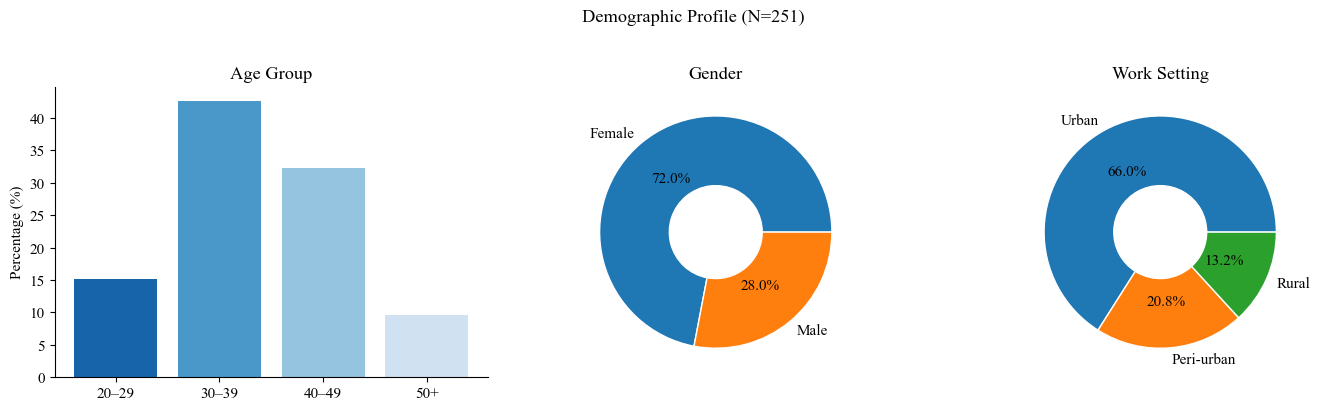

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

age_order = ["20–29", "30–39", "40–49", "50+"]
age_counts = df["B1_Age"].map(age_labels).value_counts().reindex(age_order)
axes[0].bar(age_order, age_counts / n * 100, color=sns.color_palette("Blues_r", 4))
axes[0].set_title("Age Group")
axes[0].set_ylabel("Percentage (%)")
axes[0].spines[["top", "right"]].set_visible(False)

gender_counts = df["B2_Gender"].map(gender_labels).value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            wedgeprops={"width": 0.6, "edgecolor": "white"})
axes[1].set_title("Gender")

ws_counts = df["B4_WorkSetting"].map(ws_labels).value_counts()
axes[2].pie(ws_counts, labels=ws_counts.index, autopct="%1.1f%%",
            wedgeprops={"width": 0.6, "edgecolor": "white"})
axes[2].set_title("Work Setting")

plt.suptitle(f"Demographic Profile (N={n})", y=1.02)
plt.tight_layout()
plt.show()

## 3. KAP Score Distributions

In [7]:
for score, name, max_val in [
    ("KnowledgeScore", "Knowledge", 8),
    ("AttitudeScore", "Attitude", 50),
    ("PracticeScore", "Practice", 3),
]:
    print(f"{name} score (0–{max_val}): mean={df[score].mean():.2f}, SD={df[score].std():.2f}, "
          f"min={df[score].min()}, max={df[score].max()}")

Knowledge score (0–8): mean=5.63, SD=1.46, min=0, max=8
Attitude score (0–50): mean=36.52, SD=6.50, min=0, max=50
Practice score (0–3): mean=2.20, SD=0.95, min=0, max=3


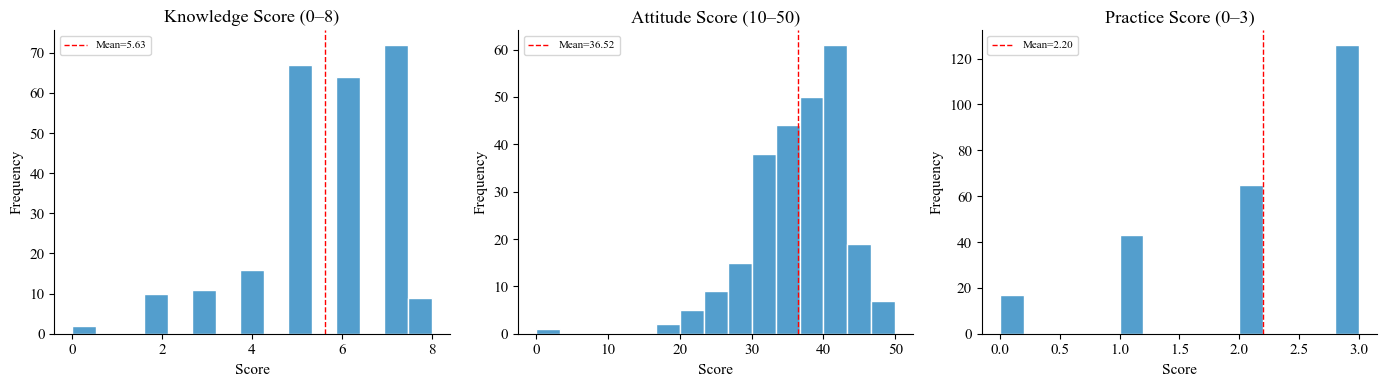

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
blue = sns.color_palette("Blues_r", 6)[2]

for ax, col, title in zip(axes,
    ["KnowledgeScore", "AttitudeScore", "PracticeScore"],
    ["Knowledge Score (0–8)", "Attitude Score (10–50)", "Practice Score (0–3)"]):
    ax.hist(df[col], bins=15, color=blue, edgecolor="white")
    ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1,
               label=f"Mean={df[col].mean():.2f}")
    ax.set_title(title)
    ax.set_xlabel("Score")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
k_cat_labels = {1: "Poor (0–4)", 2: "Moderate (5–6)", 3: "Good (7–8)"}
a_cat_labels = {1: "Negative", 2: "Neutral", 3: "Positive"}
p_cat_labels = {1: "Low", 2: "Moderate", 3: "High"}

for var, labels, name in [
    ("KnowledgeCat", k_cat_labels, "Knowledge Category"),
    ("AttitudeCat", a_cat_labels, "Attitude Category"),
    ("PracticeCat", p_cat_labels, "Practice Category"),
]:
    counts = df[var].map(labels).value_counts()
    print(f"\n{name}:")
    print(counts.to_frame().assign(pct=lambda x: (x["count"] / n * 100).round(1)))


Knowledge Category:
                count   pct
KnowledgeCat               
Moderate (5–6)    131  52.2
Good (7–8)         81  32.3
Poor (0–4)         39  15.5

Attitude Category:
             count   pct
AttitudeCat             
Neutral        132  52.6
Positive        87  34.7
Negative        32  12.7

Practice Category:
             count   pct
PracticeCat             
High           191  76.1
Moderate        43  17.1
Low             17   6.8


## 4. Item-Level Analysis

In [10]:
correct_answers = {
    "K1_InformedConsent": 1, "K2_WrittenConsent": 1, "K3_ReduceTravel": 1,
    "K4_VideoMandatory": 0, "K5_ControlledMeds": 1, "K6_DataPrivacy": 1,
    "K7_Emergencies": 0, "K8_Documentation": 1,
}
k_labels = [
    "K1: Informed consent", "K2: Written consent", "K3: Reduces travel",
    "K4: Video mandatory (False)", "K5: Controlled meds", "K6: Data privacy",
    "K7: For emergencies (False)", "K8: Documentation",
]

print("Knowledge item accuracy (% correct):")
for col, label, correct in zip(k_cols, k_labels, correct_answers.values()):
    pct_correct = (df[col] == correct).mean() * 100
    pct_dk = (df[col] == 9).mean() * 100
    print(f"  {label}: {pct_correct:.1f}% correct | {pct_dk:.1f}% Don't Know")

Knowledge item accuracy (% correct):
  K1: Informed consent: 94.8% correct | 3.2% Don't Know
  K2: Written consent: 10.0% correct | 27.5% Don't Know
  K3: Reduces travel: 96.0% correct | 2.4% Don't Know
  K4: Video mandatory (False): 59.0% correct | 31.9% Don't Know
  K5: Controlled meds: 41.4% correct | 42.6% Don't Know
  K6: Data privacy: 86.9% correct | 10.4% Don't Know
  K7: For emergencies (False): 85.7% correct | 5.6% Don't Know
  K8: Documentation: 88.8% correct | 7.6% Don't Know


In [11]:
a_labels_short = [
    "A1: Privacy threat", "A2: Rural access", "A3: Doctor-pt relation", "A4: Confidence",
    "A5: Error risk", "A6: CME tool", "A7: Cultural fit", "A8: Integration",
    "A9: Recommend", "A10: Load reduction",
]

print("Attitude item mean scores (1–5):")
for col, label in zip(a_cols, a_labels_short):
    print(f"  {label}: mean={df[col].mean():.2f}, SD={df[col].std():.2f}")

Attitude item mean scores (1–5):
  A1: Privacy threat: mean=1.97, SD=1.17
  A2: Rural access: mean=4.31, SD=1.08
  A3: Doctor-pt relation: mean=2.56, SD=1.17
  A4: Confidence: mean=3.70, SD=1.17
  A5: Error risk: mean=3.40, SD=1.03
  A6: CME tool: mean=3.60, SD=1.24
  A7: Cultural fit: mean=3.00, SD=1.00
  A8: Integration: mean=4.23, SD=1.13
  A9: Recommend: mean=3.89, SD=1.13
  A10: Load reduction: mean=3.85, SD=1.16


In [12]:
print("Practice indicators:")
print(f"  Used TM past 6 months: {(df['P1_Used6Mo']==1).sum()} ({(df['P1_Used6Mo']==1).mean()*100:.1f}%)")
print(f"  Want training: {(df['P7_WantTraining']==1).sum()} ({(df['P7_WantTraining']==1).mean()*100:.1f}%)")
print("\nConsultation volume (per month):")
print(df["P2_ConsultMonth_Ord"].map({1:"0–2",2:"3–5",3:"6–10",4:">10"}).value_counts())
print("\nDocumentation frequency:")
print(df["P4_Documentation_Ord"].map({1:"Never",2:"Rarely",3:"Sometimes",4:"Always"}).value_counts())

Practice indicators:
  Used TM past 6 months: 219 (87.3%)
  Want training: 208 (82.9%)

Consultation volume (per month):
P2_ConsultMonth_Ord
0–2     74
6–10    60
>10     60
3–5     56
Name: count, dtype: int64

Documentation frequency:
P4_Documentation_Ord
Sometimes    111
Never         47
Rarely        47
Always        45
Name: count, dtype: int64


## 5. Preliminary Associations

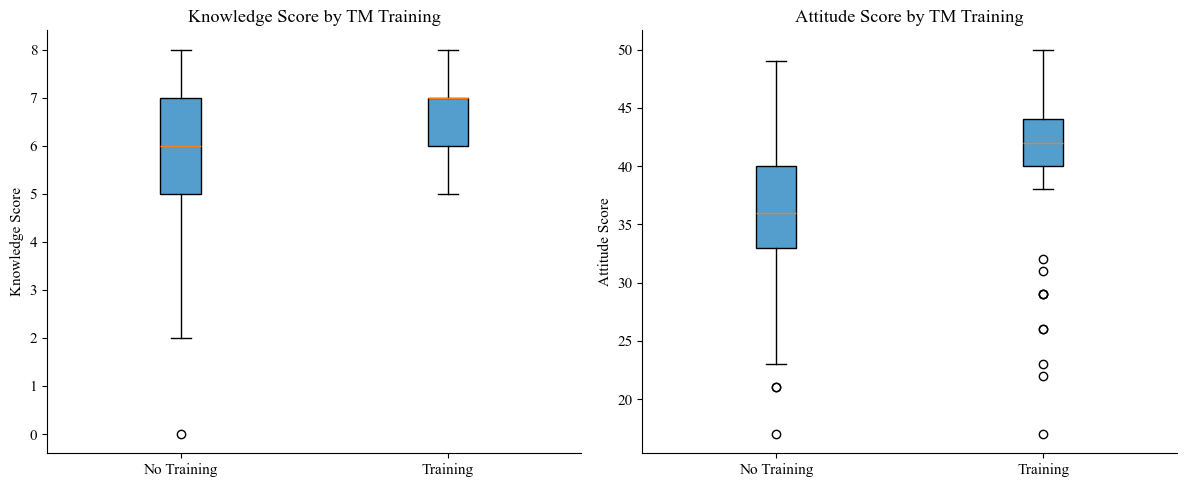

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
blue = sns.color_palette("Blues_r", 6)[2]

trained_k = df[df["B7_Training"] == 1]["KnowledgeScore"].dropna()
untrained_k = df[df["B7_Training"] == 0]["KnowledgeScore"].dropna()
axes[0].boxplot([untrained_k, trained_k], labels=["No Training", "Training"],
                patch_artist=True, boxprops={"facecolor": blue})
axes[0].set_ylabel("Knowledge Score")
axes[0].set_title("Knowledge Score by TM Training")
axes[0].spines[["top", "right"]].set_visible(False)

trained_a = df[df["B7_Training"] == 1]["AttitudeScore"].dropna()
untrained_a = df[df["B7_Training"] == 0]["AttitudeScore"].dropna()
axes[1].boxplot([untrained_a, trained_a], labels=["No Training", "Training"],
                patch_artist=True, boxprops={"facecolor": blue})
axes[1].set_ylabel("Attitude Score")
axes[1].set_title("Attitude Score by TM Training")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
associations = [
    ("KnowledgeCat", "AttitudeCat", "Knowledge × Attitude"),
    ("KnowledgeCat", "PracticeCat", "Knowledge × Practice"),
    ("AttitudeCat", "PracticeCat", "Attitude × Practice"),
    ("B7_Training", "KnowledgeCat", "Training × Knowledge"),
    ("B7_Training", "AttitudeCat", "Training × Attitude"),
]

print("Chi-square associations:")
for var1, var2, label in associations:
    ct = pd.crosstab(df[var1], df[var2])
    chi2, p, dof, _ = chi2_contingency(ct)
    print(f"  {label}: χ²({dof}) = {chi2:.2f}, p = {p:.4f}")

Chi-square associations:
  Knowledge × Attitude: χ²(4) = 34.87, p = 0.0000
  Knowledge × Practice: χ²(4) = 44.44, p = 0.0000
  Attitude × Practice: χ²(4) = 33.62, p = 0.0000
  Training × Knowledge: χ²(2) = 22.85, p = 0.0000
  Training × Attitude: χ²(2) = 49.59, p = 0.0000


## 6. Correlation Analysis

In [15]:
score_cols = ["KnowledgeScore", "AttitudeScore", "PracticeScore"]

print("Spearman correlations among KAP scores:")
for i, col1 in enumerate(score_cols):
    for col2 in score_cols[i+1:]:
        r, p = stats.spearmanr(df[col1].dropna(), df.loc[df[col1].notna(), col2])
        print(f"  {col1} × {col2}: ρ = {r:.3f}, p = {p:.4f}")

print("\nSpearman: Knowledge score vs Attitude score")
r, p = stats.spearmanr(df["KnowledgeScore"], df["AttitudeScore"])
print(f"  ρ = {r:.3f}, p = {p:.4f}")

Spearman correlations among KAP scores:
  KnowledgeScore × AttitudeScore: ρ = 0.423, p = 0.0000
  KnowledgeScore × PracticeScore: ρ = 0.451, p = 0.0000
  AttitudeScore × PracticeScore: ρ = 0.378, p = 0.0000

Spearman: Knowledge score vs Attitude score
  ρ = 0.423, p = 0.0000


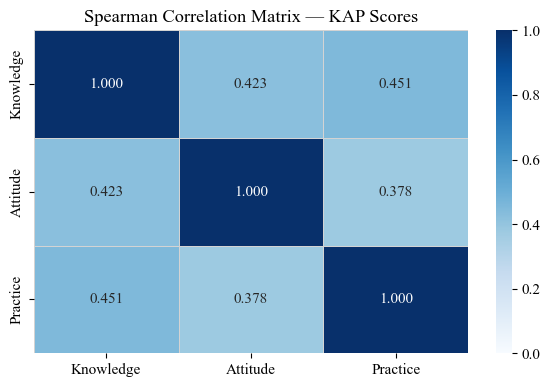

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
corr = df[score_cols].corr(method="spearman")
corr.index = ["Knowledge", "Attitude", "Practice"]
corr.columns = ["Knowledge", "Attitude", "Practice"]
sns.heatmap(corr, annot=True, fmt=".3f", cmap="Blues",
            vmin=0, vmax=1, linewidths=0.5, linecolor="lightgray", ax=ax)
ax.set_title("Spearman Correlation Matrix — KAP Scores")
plt.tight_layout()
plt.show()

## 7. EDA Findings Summary

| Finding | Value |
|---------|-------|
| Sample size | N = 251 |
| Female participants | 72.1% |
| Urban work setting | 66.1% |
| Most common age group | 30–39 years (43.0%) |
| Received TM training | 17.9% |
| Mean knowledge score (0–8) | 5.63 ± 1.46 |
| Good knowledge (7–8) | 32.3% |
| Mean attitude score (10–50) | 36.67 ± 6.08 |
| Positive attitude (40–50) | 34.7% |
| Used TM in past 6 months | 87.6% |
| High practice category | 76.1% |
| Most used platform | Phone call (86.5%) |
| Top barrier | Poor internet (94.8%) |
| Top support need | Technical training (91.6%) |
| Knowledge × Attitude association | χ²(4) = 32.42, p < 0.001 |
| Training → positive attitude | 75.6% vs 25.7% (p < 0.001) |